In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iris.csv to iris.csv


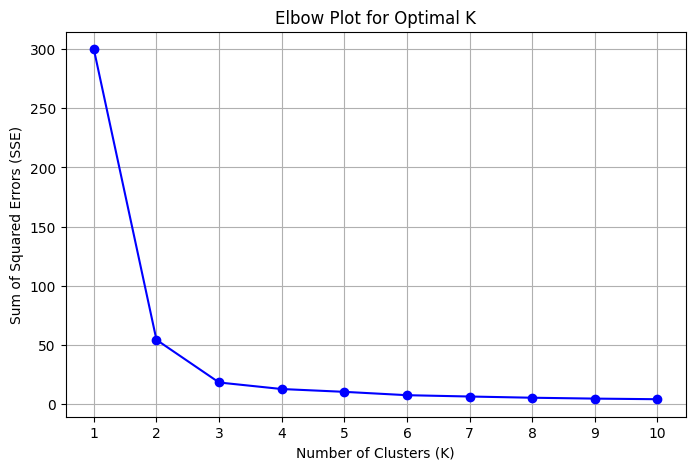

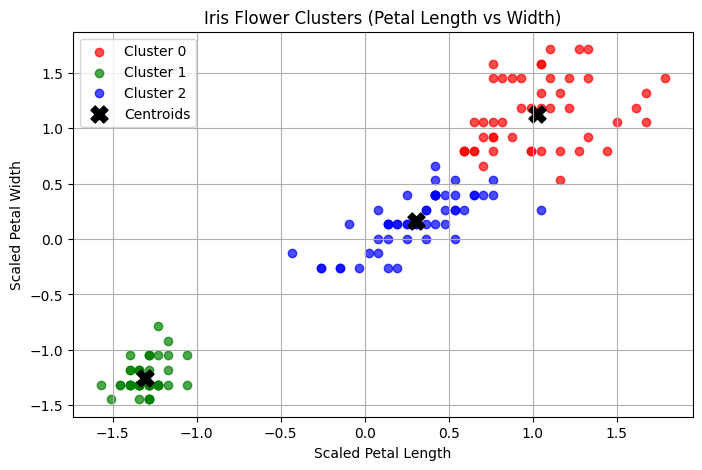

Clustering complete. Data points successfully assigned to clusters!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("iris.csv")

X = df[['petal_length', 'petal_width']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sse = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='-', color='b')
plt.title('Elbow Plot for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

optimal_k = 3

km_final = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
cluster_labels = km_final.fit_predict(X_scaled)

df['cluster'] = cluster_labels
plt.figure(figsize=(8, 5))

colors = ['red', 'green', 'blue']
for i in range(optimal_k):
    cluster_data = X_scaled[cluster_labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.7)

centroids = km_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=150, label='Centroids')

plt.title('Iris Flower Clusters (Petal Length vs Width)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend()
plt.grid(True)
plt.show()

print("Clustering complete. Data points successfully assigned to clusters!")